Current directory: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code
PyTheus directory: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Data/runtime_data/pytheus_data_time
Surrogate directory: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Data/runtime_data/surrogate_optimisation
Output directory: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Results/runtime_bar

Checking input files...
GHZ, n=4
  PyTheus  : /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Data/runtime_data/pytheus_data_time/GHZ/4n_time_info.json True
  Surrogate: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Data/runtime_data/surrogate_optimisation/GHZ/4n.json True
GHZ, n=6
  PyTheus  : /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Data/runtime_data/pytheus_data_time/GHZ/6n_time_info.json True
  Surrogate: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Data/runtime_data/surrogate

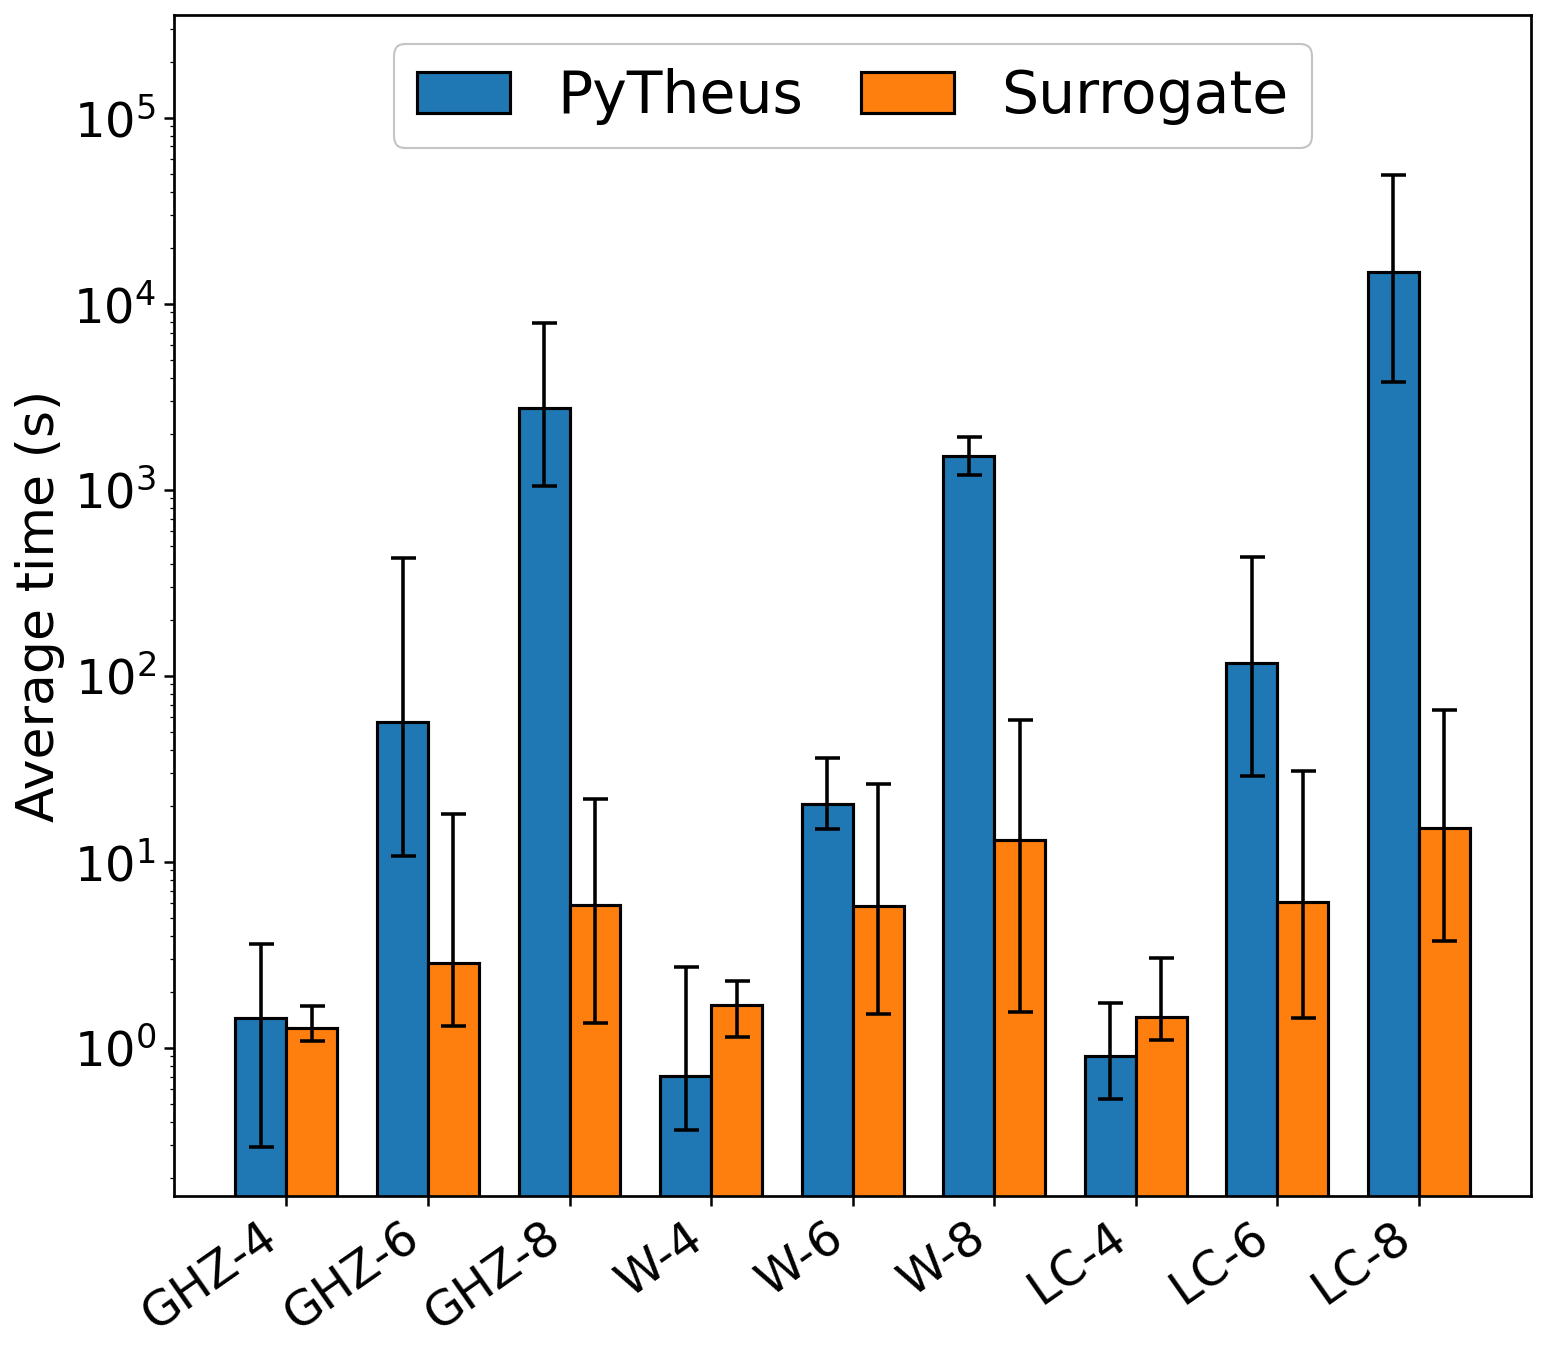

Saved PNG: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Results/runtime_bar/grouped_runtime_barplot_pytheus_vs_surrogate_minmax_linear.png
Saved PDF: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Results/runtime_bar/grouped_runtime_barplot_pytheus_vs_surrogate_minmax_linear.pdf


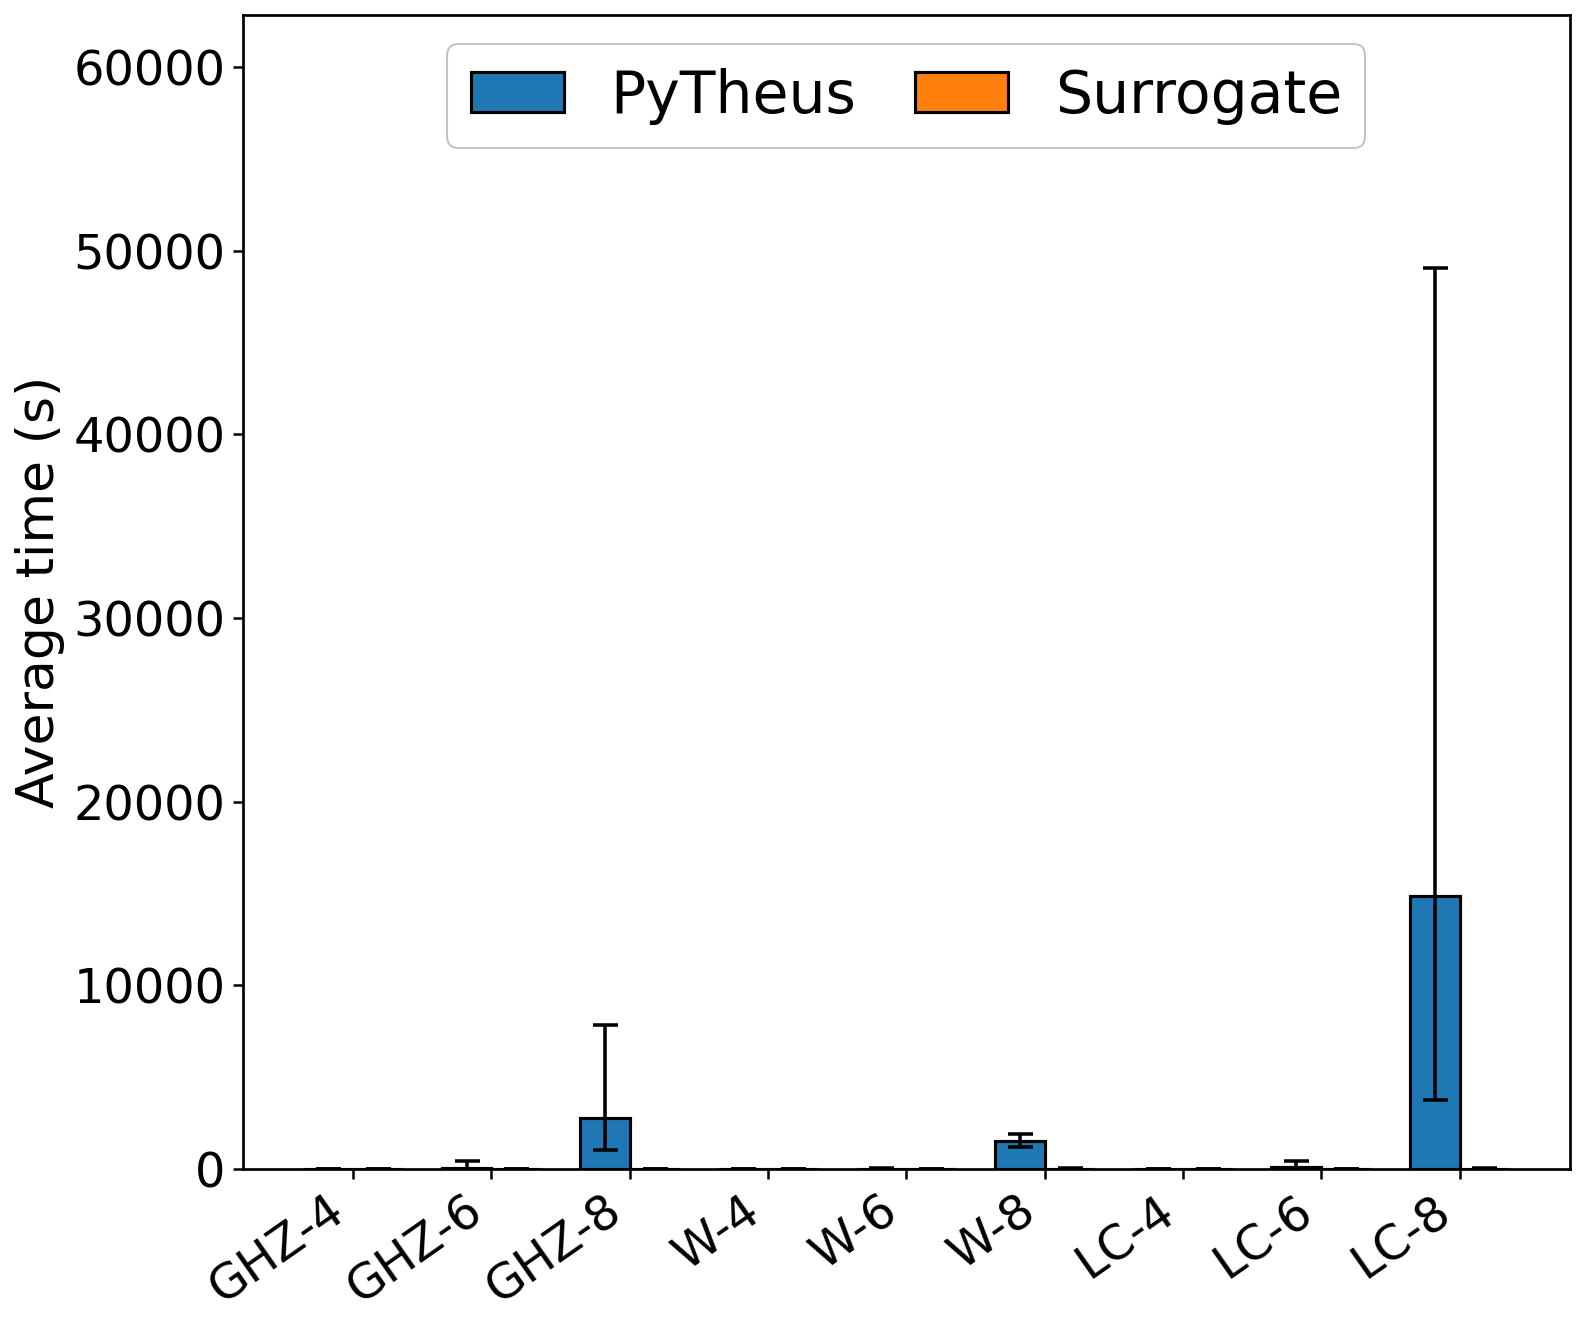

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# DIRECTORY CONFIGURATION
# ============================================================

ROOT = Path.cwd()

PYTHEUS_DIR = ROOT / "Data" / "runtime_data" / "pytheus_data_time"
SURROGATE_DIR = ROOT / "Data" / "runtime_data" / "surrogate_optimisation"

OUTPUT_DIR = ROOT / "Results" / "runtime_bar"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Current directory:", ROOT)
print("PyTheus directory:", PYTHEUS_DIR)
print("Surrogate directory:", SURROGATE_DIR)
print("Output directory:", OUTPUT_DIR)


# ============================================================
# FILE PATHS
# ============================================================

STATES = ["GHZ", "W", "LC"]
NODES = [4, 6, 8]

FILES_PYTHEUS = {
    state: {
        n: PYTHEUS_DIR / state / f"{n}n_time_info.json"
        for n in NODES
    }
    for state in STATES
}

FILES_SURROGATE = {
    state: {
        n: SURROGATE_DIR / state / f"{n}n.json"
        for n in NODES
    }
    for state in STATES
}


# ============================================================
# USER SETTINGS
# ============================================================

MAX_SAMPLES = 50
SAVE_TXT_SUMMARY = True


# ============================================================
# PAPER-LIKE MATPLOTLIB STYLE
# ============================================================

plt.rcParams.update({
    "font.size": 28,
    "axes.titlesize": 30,
    "axes.labelsize": 34,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 28,

    "lines.linewidth": 2.4,
    "axes.linewidth": 1.3,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 5.0,
    "ytick.major.size": 5.0,

    "figure.dpi": 150,
    "savefig.dpi": 600,

    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# STYLE CONFIG
# ============================================================

FIGSIZE_BAR = (11.5, 10)

BAR_WIDTH = 0.36
BAR_EDGE_WIDTH = 1.5
ERROR_BAR_CAPSIZE = 6
ERROR_BAR_LINEWIDTH = 1.7

LABEL_FONTSIZE = 28
TICK_FONTSIZE = 23
AXIS_LABEL_FONTSIZE_SMALL = 25

LEGEND_FRAME_ALPHA = 0.92
LEGEND_EDGE_COLOR = "0.75"


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def check_file(path: Path, label: str):
    """Check whether an input file exists."""
    if not path.exists():
        raise FileNotFoundError(f"{label} not found:\n{path}")
    return path


def load_json(path: Path):
    """Load JSON file."""
    with open(path, "r") as f:
        return json.load(f)


def clean_time_array(times, max_samples=50):
    """
    Convert time list to clean float array.
    Removes invalid, None, NaN, and inf values.
    Keeps only first max_samples entries.
    """
    cleaned = []

    for value in times:
        try:
            value = float(value)
            if np.isfinite(value):
                cleaned.append(value)
        except (TypeError, ValueError):
            continue

    cleaned = np.array(cleaned, dtype=float)

    if max_samples is not None:
        cleaned = cleaned[:max_samples]

    return cleaned


def extract_pytheus_time(path: Path):
    """Extract PyTheus pre-topological-optimisation time."""
    check_file(path, "PyTheus time file")
    data = load_json(path)

    if "Time_pre_opt" not in data:
        raise KeyError(
            f"'Time_pre_opt' not found in PyTheus file:\n{path}\n"
            f"Available keys: {list(data.keys())}"
        )

    return clean_time_array(data["Time_pre_opt"], max_samples=MAX_SAMPLES)


def extract_surrogate_time(path: Path):
    """
    Extract surrogate time per sample.

    Uses [1:51] because the first timing value is often a warm-up
    or compilation-related outlier.
    """
    check_file(path, "Surrogate optimisation summary file")
    data = load_json(path)

    if "time_per_sample" not in data:
        raise KeyError(
            f"'time_per_sample' not found in surrogate file:\n{path}\n"
            f"Available keys: {list(data.keys())}"
        )

    times = data["time_per_sample"][1:MAX_SAMPLES + 1]
    return clean_time_array(times, max_samples=MAX_SAMPLES)


def get_mean_and_minmax_error(times):
    """
    Return mean and asymmetric min-max error bars.
    """
    times = np.asarray(times, dtype=float)

    if len(times) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    mean_time = np.mean(times)
    min_time = np.min(times)
    max_time = np.max(times)
    std_time = np.std(times)

    lower_error = mean_time - min_time
    upper_error = max_time - mean_time

    return mean_time, lower_error, upper_error, min_time, max_time


def style_axis(ax):
    """Apply consistent paper-style axis formatting."""
    ax.grid(False)

    ax.tick_params(
        axis="both",
        labelsize=TICK_FONTSIZE,
        width=1.2,
        length=5.0,
        direction="out",
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.3)


def add_non_overlapping_legend(ax, log_scale=False):
    """Place legend inside the axes, in headroom reserved above the bars
    (added to the y-limit) so the legend box never touches a bar."""
    bottom, top = ax.get_ylim()

    if log_scale:
        # widen the top of a log-scale axis multiplicatively
        top = top * (10 ** 0.6)
    else:
        top = top + 0.22 * (top - bottom)

    ax.set_ylim(bottom, top)

    ax.legend(
        loc="upper center",
        ncol=2,
        frameon=True,
        framealpha=LEGEND_FRAME_ALPHA,
        edgecolor=LEGEND_EDGE_COLOR,
        handlelength=1.6,
        borderpad=0.4,
        labelspacing=0.3,
        columnspacing=1.0,
    )


def save_and_show_plot(fig, filename):
    """Save PNG/PDF and show the plot in notebook."""
    png_path = OUTPUT_DIR / f"{filename}.png"
    pdf_path = OUTPUT_DIR / f"{filename}.pdf"

    fig.tight_layout(pad=1.5)
    fig.savefig(png_path, dpi=600, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")

    plt.show()
    plt.close(fig)


# ============================================================
# CHECK INPUT FILES
# ============================================================

print("\nChecking input files...")

for state in STATES:
    for n in NODES:
        print(f"{state}, n={n}")
        print("  PyTheus  :", FILES_PYTHEUS[state][n], FILES_PYTHEUS[state][n].exists())
        print("  Surrogate:", FILES_SURROGATE[state][n], FILES_SURROGATE[state][n].exists())


# ============================================================
# LOAD ALL TIME DATA
# ============================================================

time_data = {
    state: {
        "PyTheus": {},
        "Surrogate": {},
    }
    for state in STATES
}

stats_data = {
    state: {
        "PyTheus": {},
        "Surrogate": {},
    }
    for state in STATES
}

for state in STATES:
    for n in NODES:
        py_times = extract_pytheus_time(FILES_PYTHEUS[state][n])
        surrogate_times = extract_surrogate_time(FILES_SURROGATE[state][n])

        time_data[state]["PyTheus"][n] = py_times
        time_data[state]["Surrogate"][n] = surrogate_times

        py_mean, py_lower, py_upper, py_min, py_max = get_mean_and_minmax_error(py_times)
        su_mean, su_lower, su_upper, su_min, su_max = get_mean_and_minmax_error(surrogate_times)

        stats_data[state]["PyTheus"][n] = {
            "mean": py_mean,
            "lower": py_lower,
            "upper": py_upper,
            "min": py_min,
            "max": py_max,
            "std": np.std(py_times),
            "num_samples": len(py_times),
        }

        stats_data[state]["Surrogate"][n] = {
            "mean": su_mean,
            "lower": su_lower,
            "upper": su_upper,
            "min": su_min,
            "max": su_max,
            "std": np.std(surrogate_times),
            "num_samples": len(surrogate_times),
        }

        print("=" * 70)
        print(f"{state}, n={n}")
        print(f"PyTheus samples      : {len(py_times)}")
        print(f"Surrogate samples    : {len(surrogate_times)}")
        print(f"PyTheus mean time    : {py_mean:.6f}")
        print(f"PyTheus min/max time : {py_min:.6f} / {py_max:.6f}")
        print(f"Surrogate mean time  : {su_mean:.6f}")
        print(f"Surrogate min/max    : {su_min:.6f} / {su_max:.6f}")


# ============================================================
# SAVE NUMERICAL SUMMARY
# ============================================================

if SAVE_TXT_SUMMARY:
    summary_path = OUTPUT_DIR / "runtime_barplot_summary_minmax.txt"

    with open(summary_path, "w") as f:
        for state in STATES:
            f.write(f"\n{state}\n")
            f.write("=" * 80 + "\n")

            for n in NODES:
                py = stats_data[state]["PyTheus"][n]
                su = stats_data[state]["Surrogate"][n]

                f.write(
                    f"n={n} | "
                    f"PyTheus samples={py['num_samples']}, "
                    f"PyTheus mean={py['mean']:.10f}, "
                    f"PyTheus std={py['std']:.10f}, "
                    f"PyTheus min={py['min']:.10f}, "
                    f"PyTheus max={py['max']:.10f}, "
                    f"Surrogate samples={su['num_samples']}, "
                    f"Surrogate mean={su['mean']:.10f}, "
                    f"Surrogate std={su['std']:.10f}, "
                    f"Surrogate min={su['min']:.10f}, "
                    f"Surrogate max={su['max']:.10f}\n"
                )

    print(f"Saved summary: {summary_path}")


# ============================================================
# PREPARE PLOT DATA
# ============================================================

labels = []
py_means = []
su_means = []

py_lower_errors = []
py_upper_errors = []
su_lower_errors = []
su_upper_errors = []

for state in STATES:
    for n in NODES:
        labels.append(f"{state}-{n}")

        py = stats_data[state]["PyTheus"][n]
        su = stats_data[state]["Surrogate"][n]

        py_means.append(py["mean"])
        su_means.append(su["mean"])

        py_lower_errors.append(py["lower"])
        py_upper_errors.append(py["upper"])

        su_lower_errors.append(su["lower"])
        su_upper_errors.append(su["upper"])


x = np.arange(len(labels))

py_means = np.array(py_means)
su_means = np.array(su_means)

py_yerr = np.array([py_lower_errors, py_upper_errors])
su_yerr = np.array([su_lower_errors, su_upper_errors])


# ============================================================
# PLOT 1: GROUPED BAR PLOT, LOG Y-AXIS
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE_BAR)

ax.bar(
    x - BAR_WIDTH / 2,
    py_means,
    width=BAR_WIDTH,
    yerr=py_yerr,
    capsize=ERROR_BAR_CAPSIZE,
    error_kw={
        "elinewidth": ERROR_BAR_LINEWIDTH,
        "capthick": ERROR_BAR_LINEWIDTH,
    },
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    label="PyTheus",
)

ax.bar(
    x + BAR_WIDTH / 2,
    su_means,
    width=BAR_WIDTH,
    yerr=su_yerr,
    capsize=ERROR_BAR_CAPSIZE,
    error_kw={
        "elinewidth": ERROR_BAR_LINEWIDTH,
        "capthick": ERROR_BAR_LINEWIDTH,
    },
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    label="Surrogate",
)

ax.set_ylabel("Average time (s)", fontsize=AXIS_LABEL_FONTSIZE_SMALL)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=AXIS_LABEL_FONTSIZE_SMALL)

ax.set_yscale("log")

style_axis(ax)
ax.set_box_aspect(0.87)
add_non_overlapping_legend(ax, log_scale=True)

save_and_show_plot(
    fig,
    "grouped_runtime_barplot_pytheus_vs_surrogate_minmax_logscale"
)


# ============================================================
# PLOT 2: GROUPED BAR PLOT, LINEAR Y-AXIS
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE_BAR)

ax.bar(
    x - BAR_WIDTH / 2,
    py_means,
    width=BAR_WIDTH,
    yerr=py_yerr,
    capsize=ERROR_BAR_CAPSIZE,
    error_kw={
        "elinewidth": ERROR_BAR_LINEWIDTH,
        "capthick": ERROR_BAR_LINEWIDTH,
    },
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    label="PyTheus",
)

ax.bar(
    x + BAR_WIDTH / 2,
    su_means,
    width=BAR_WIDTH,
    yerr=su_yerr,
    capsize=ERROR_BAR_CAPSIZE,
    error_kw={
        "elinewidth": ERROR_BAR_LINEWIDTH,
        "capthick": ERROR_BAR_LINEWIDTH,
    },
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    label="Surrogate",
)

ax.set_ylabel("Average time (s)", fontsize=AXIS_LABEL_FONTSIZE_SMALL)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=AXIS_LABEL_FONTSIZE_SMALL)

style_axis(ax)
ax.set_box_aspect(0.87)
add_non_overlapping_legend(ax, log_scale=False)

save_and_show_plot(
    fig,
    "grouped_runtime_barplot_pytheus_vs_surrogate_minmax_linear"
)